In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


Text(0.5, 0, 'ns')

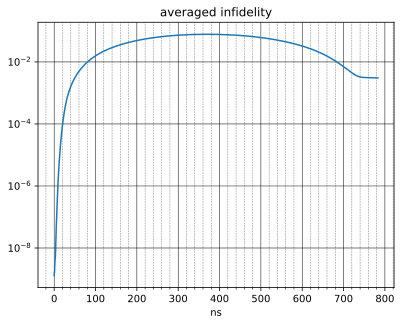

In [3]:

t_rise = 30
square_t_stop = 733
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall)

tot_time = int(t_stop + 20)
tlist = np.linspace(0, tot_time, tot_time)


all_results = []
for i in [2,3,4,5]:
    with open(f'../pickles/mcsolve_three_outcome_state{i}_233_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)


results = [all_results[0],all_results[1],all_results[2],all_results[3]]

num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
# states_ideal  = [zero,
#                 one,
#                 (zero +  one).unit(),
#                 (zero - one).unit(),
#                 (zero + 1j * one).unit(),
#                 (zero - 1j * one).unit()  ]

states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

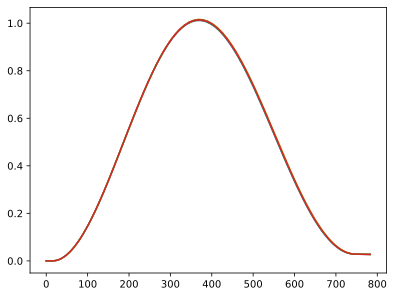

In [12]:
for result in results:
    plt.plot(result.times, result.expect[1])

# plt.ylim(0,0.1)

In [13]:
qubit_level = 25
osc_level = 30

kappa = 1e-3

system = fluxonium_oscillator_system(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa =kappa,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(20) ]+ \
                    [[ql, ol] for ql in [9,10,11] for ol in range(10) ],
    computaional_states = '1,2',
    w_d = 7.16475
    )

interactive_heatmap(results[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=782), Output(…

Text(0.5, 0, 'ns')

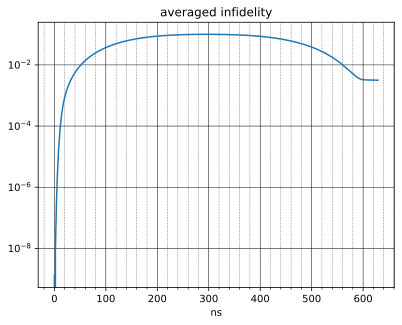

In [16]:
t_rise = 15
square_t_stop = 594.3
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall)

tot_time = int(t_stop + 20)
tlist = np.linspace(0, tot_time, tot_time)


all_results = []
for i in [2,3,4,5]:
    with open(f'../pickles/mcsolve_three_outcome_state{i}_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)


results = [all_results[0],all_results[1],all_results[2],all_results[3]]

num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
# states_ideal  = [zero,
#                 one,
#                 (zero +  one).unit(),
#                 (zero - one).unit(),
#                 (zero + 1j * one).unit(),
#                 (zero - 1j * one).unit()  ]

states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")